In [1]:
import pysam
import pandas as pd
import numpy as np
import tqdm
import gc

from Bio.pairwise2 import format_alignment
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt


In [2]:

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})


In [3]:
block_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/dag/block_df_with_align_pairs_correct.pkl")

In [4]:
baseline_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/baseline/block_df_with_align_pairs_correct.pkl")
baseline_polya_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/baseline_polya/block_df_with_align_pairs_correct.pkl")

In [14]:

def plot_pr_curve(df_dict, total_count):

    fig, ax = plt.subplots(1, 1, figsize=(20, 20))
    for name, block_df in df_dict.items():
        x = 100 - block_df["penalty"]
        y = block_df["correct"]
        precision, recall, _ = precision_recall_curve(y, x)
        recall = recall * (np.sum(y) / total_count)
        recall = np.concatenate([ [1], recall])
        precision = np.concatenate([ [0], precision])
        print(recall, precision)
        pr_auc = auc(recall, precision)
        ax.plot(recall, precision, label=f"{name}, PRAUC = {pr_auc:.4f}")
        ## Draw line at 99.95% precision
        idx = np.argmax(precision >= 0.99949)
        ax.axvline(recall[idx], color = "black", linestyle = "--")
        ax.text(recall[idx], 0.9995, f"{recall[idx]:.4f}", fontsize = 20)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/plot/pr_curve.pdf")
    plt.show()
    return None

[1.         0.91197096 0.90931113 0.9065175  0.90311959 0.90107242
 0.89704188 0.88400383 0.88073377 0.86919772 0.84584007 0.83980141
 0.82512389 0.7746643  0.75237896 0.        ] [0.         0.97788208 0.97878093 0.9807159  0.98122911 0.98277793
 0.98327541 0.98709187 0.98744827 0.98848867 0.99112386 0.9916007
 0.99156618 0.9994682  0.99949939 1.        ]
[1.         0.43962954 0.43962934 0.43962175 0.43946422 0.43924053
 0.43904153 0.4388699  0.43716802 0.43420645 0.42578679 0.42008912
 0.39861065 0.38832807 0.        ] [0.         0.82554405 0.82689285 0.83078368 0.84481762 0.87949071
 0.90449883 0.91938504 0.92773772 0.93402005 0.99496221 0.99575534
 0.99981808 0.99983764 1.        ]
[1.         0.1287343  0.12873386 0.12872207 0.12833573 0.12787266
 0.12752378 0.12731606 0.1263633  0.12502641 0.12132336 0.1190242
 0.10626545 0.10319847 0.        ] [0.         0.49845691 0.50016311 0.50637968 0.53438317 0.61079439
 0.68665534 0.7277282  0.75329123 0.76392822 0.98719895 0.98864969
 

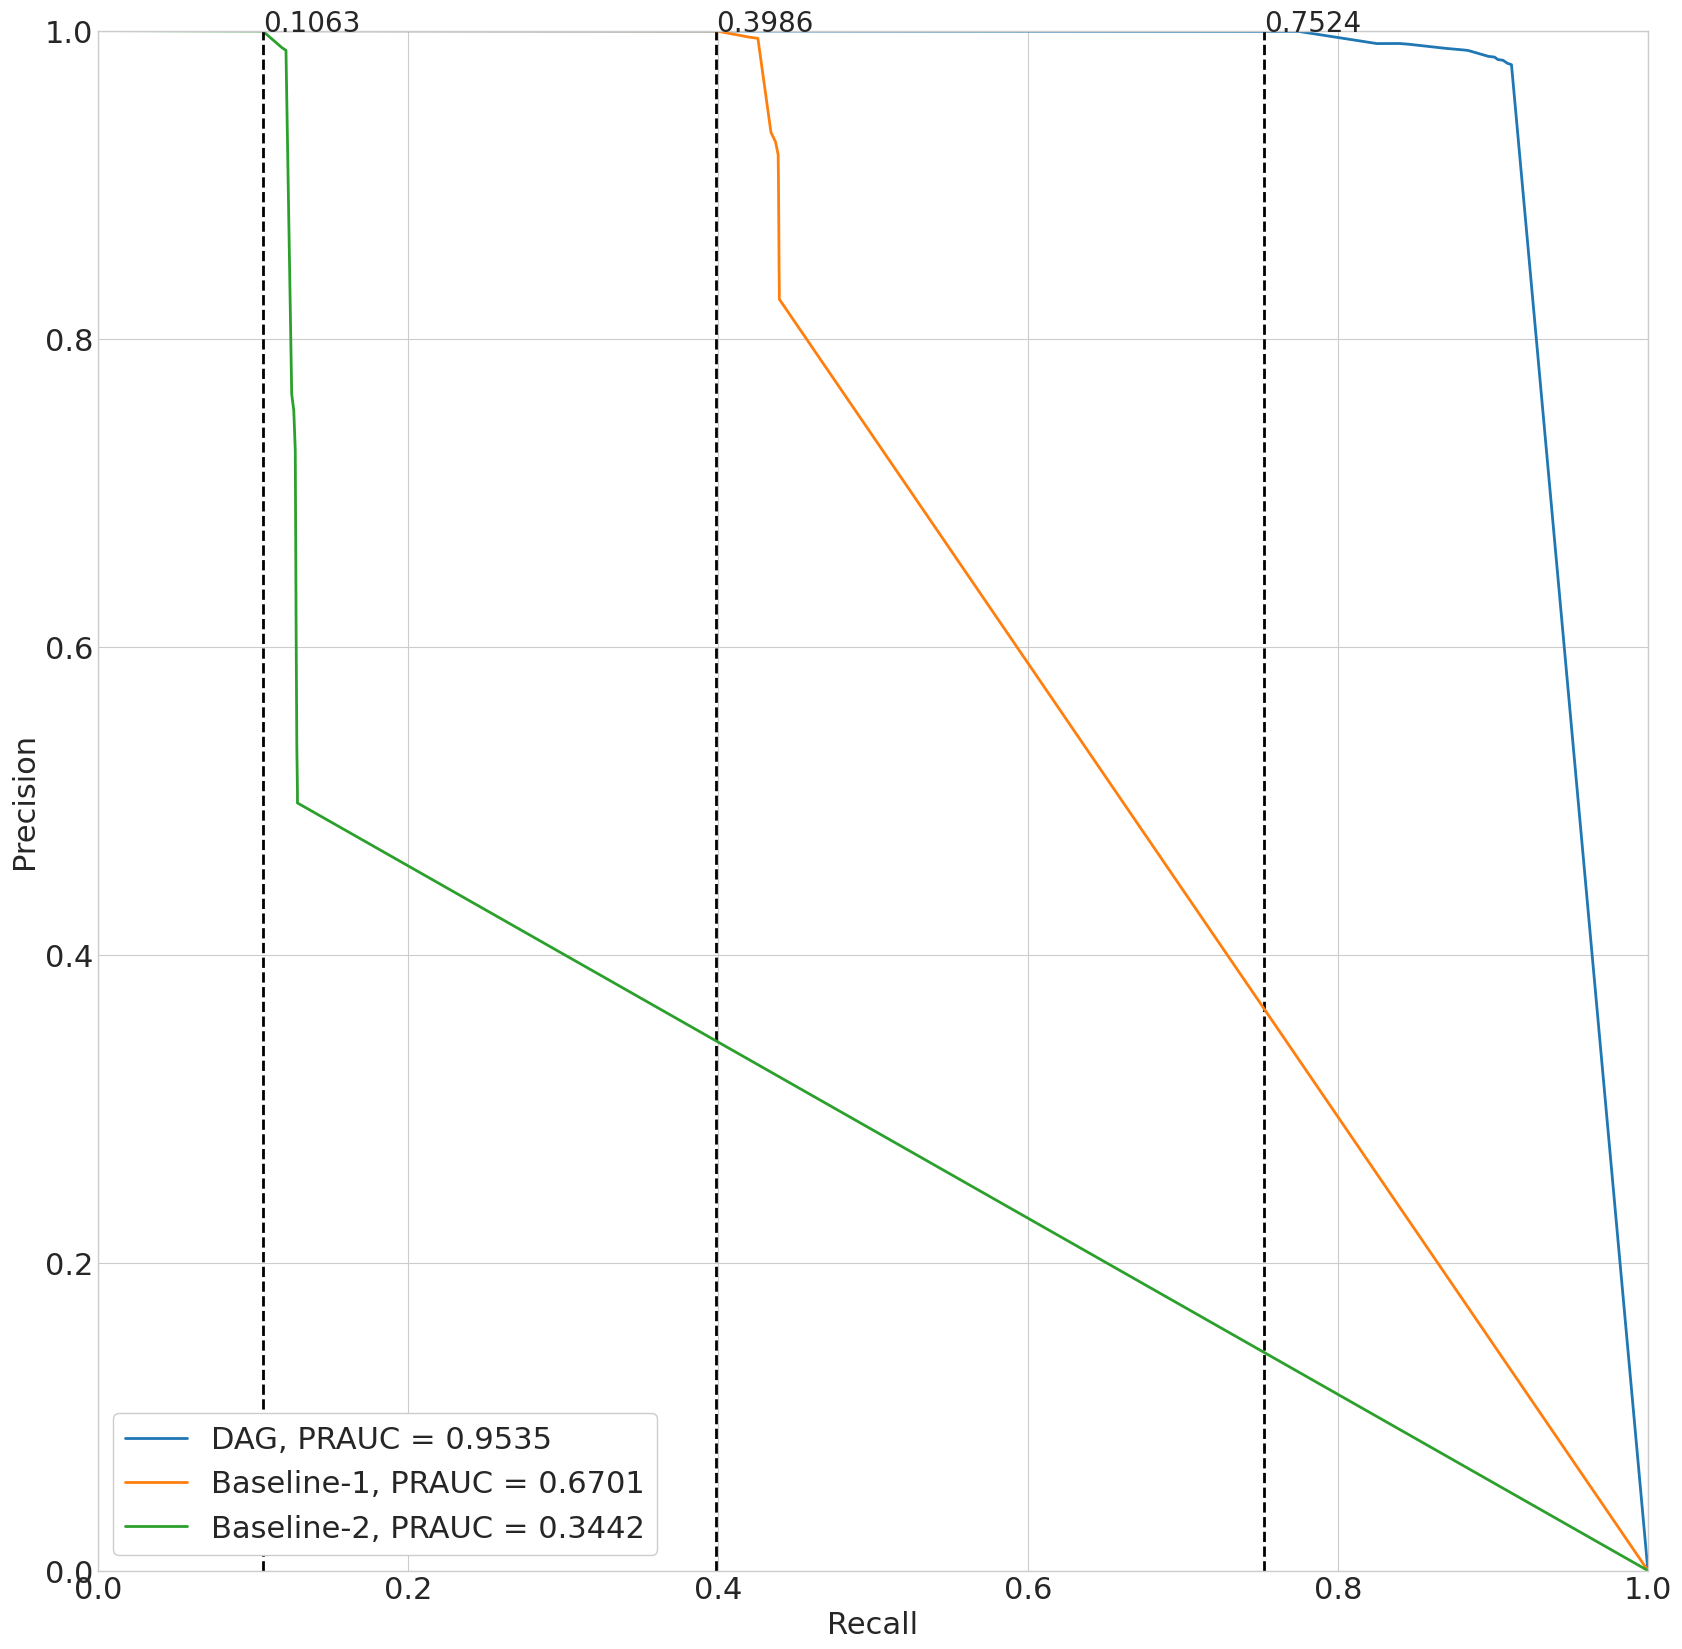

In [15]:
df_dict = {"DAG": block_df, "Baseline-1": baseline_df, "Baseline-2": baseline_polya_df}
plot_pr_curve(df_dict, 20282170)

In [16]:
ref_fasta = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/reference/ON0095_ref.fasta"
ref_fasta = pysam.FastaFile(ref_fasta)
ref_seq = ref_fasta.fetch("pentamer")
ref_seq = ref_seq.upper().replace("T", "U")
print(ref_seq)

GGGCGACAUGAGCUCUAGGAAGCUCAAACUCCAUUGUGAUCCUGCGAGCAAGCUAAAAAGCGUUUCCGGAAGAACCUGCGGGAGGUAGUCCGACAUGCUCCGAUGGAACAGUGGCUGCCAUUGCAGACUGUGCACCCUUUGGUUAAGCGUACACAUAACUACUGGGCCAGAGUAGUCCGACAUCCCCAGGACCACUGCUGUCCUCCAUUGGCAGCUUCUUAUUGGAGUCUGAAGCGUAGGCUAGCGAACGUCGAUCUGGUAGUCCGACAUCCUUCAGGCCAGUGUGAGCCUCCAUUGGCUCUGCAAGAAGUGAGUGUAAAGCGUCAGCUGGCUUAGCCAGGCUCGGUAGUCCGACAUGUGGACACCCAUGGCCCUCUCCCAUUGGGCAGAGCCGACAGUGUUUCUAAGCGUCAGGGAUGUGACUGAGGCCCAGUAGUCAUCACCUGUAAGUCGGACGAAUU


In [17]:
import polyleven
def get_leven(ref, query, pos_RM, align_pairs, pad = 10):
    pos_RM_ref = align_pairs[pos_RM]
    ref = ref[pos_RM_ref - pad: pos_RM_ref + pad + 1]
    if pad < 10:
        query = query[(10-pad):-(10-pad)]
    leven = polyleven.levenshtein(ref, query)
    return leven

In [18]:
block_df_samp = block_df[block_df["correct"] & (block_df["penalty"]==0)].copy()

In [19]:
block_df_samp["leven_21"] = block_df_samp.apply(lambda x: get_leven(ref_seq, x["motif"], x["pos_RM"], x["align_pairs"], pad = 10), axis = 1)

In [20]:
block_df_samp["leven_11"] = block_df_samp.apply(lambda x: get_leven(ref_seq, x["motif"], x["pos_RM"], x["align_pairs"], pad = 5), axis = 1)

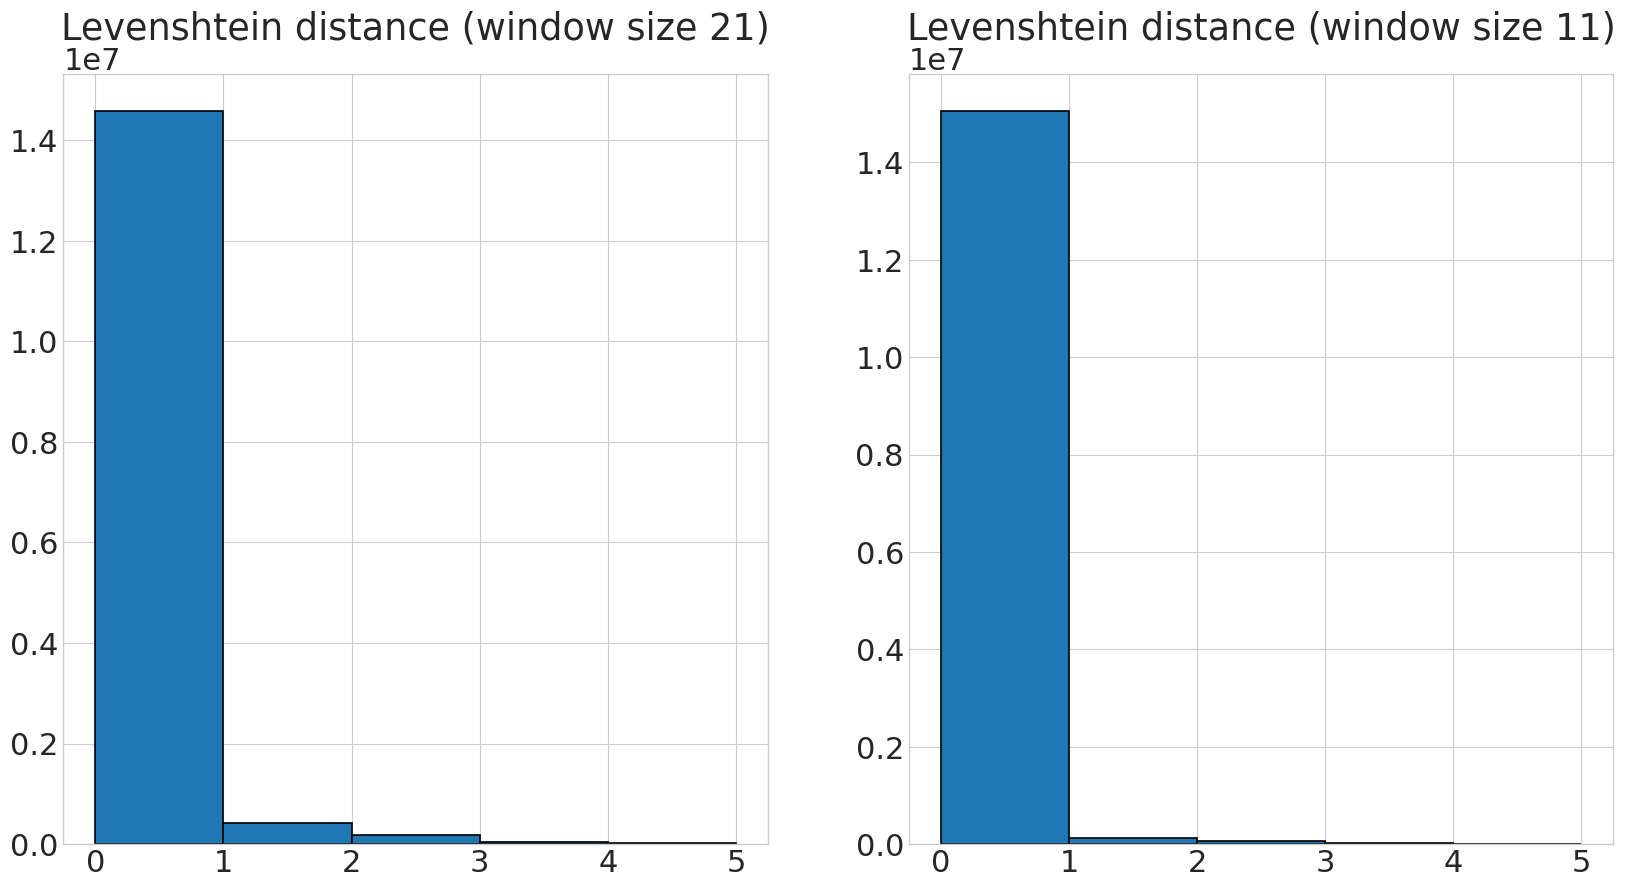

In [21]:
## Plot histogram
fig, ax = plt.subplots(1, 2, figsize = (20, 10))
a = block_df_samp["leven_21"].clip(0, 4)
ax[0].hist(a, bins = 5, range = (0, 5), edgecolor = "black", linewidth = 1.2)
ax[0].set_title("Levenshtein distance (window size 21)")
a = block_df_samp["leven_11"].clip(0, 4)
ax[1].hist(a, bins = 5, range = (0, 5), edgecolor = "black", linewidth = 1.2)
ax[1].set_title("Levenshtein distance (window size 11)")
plt.show()



In [22]:
def get_ident(ref, query, pos_RM, align_pairs, pad = 10):
    pos_RM_ref = align_pairs[pos_RM]
    ref = ref[pos_RM_ref - pad: pos_RM_ref + pad + 1]
    if pad < 10:
        query = query[(10-pad):-(10-pad)]
    rer = np.array(list(ref))
    qer = np.array(list(query))
    ident = (rer == qer)
    return ident


In [23]:
block_df_samp["ident_11"] = block_df_samp.apply(lambda x: get_ident(ref_seq, x["motif"], x["pos_RM"], x["align_pairs"], pad = 5), axis = 1)

In [24]:
block_df_samp["ident_21"] = block_df_samp.apply(lambda x: get_ident(ref_seq, x["motif"], x["pos_RM"], x["align_pairs"], pad = 10), axis = 1)

In [25]:
ident_arr = np.stack(block_df_samp["ident_21"].values)
print(ident_arr)

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


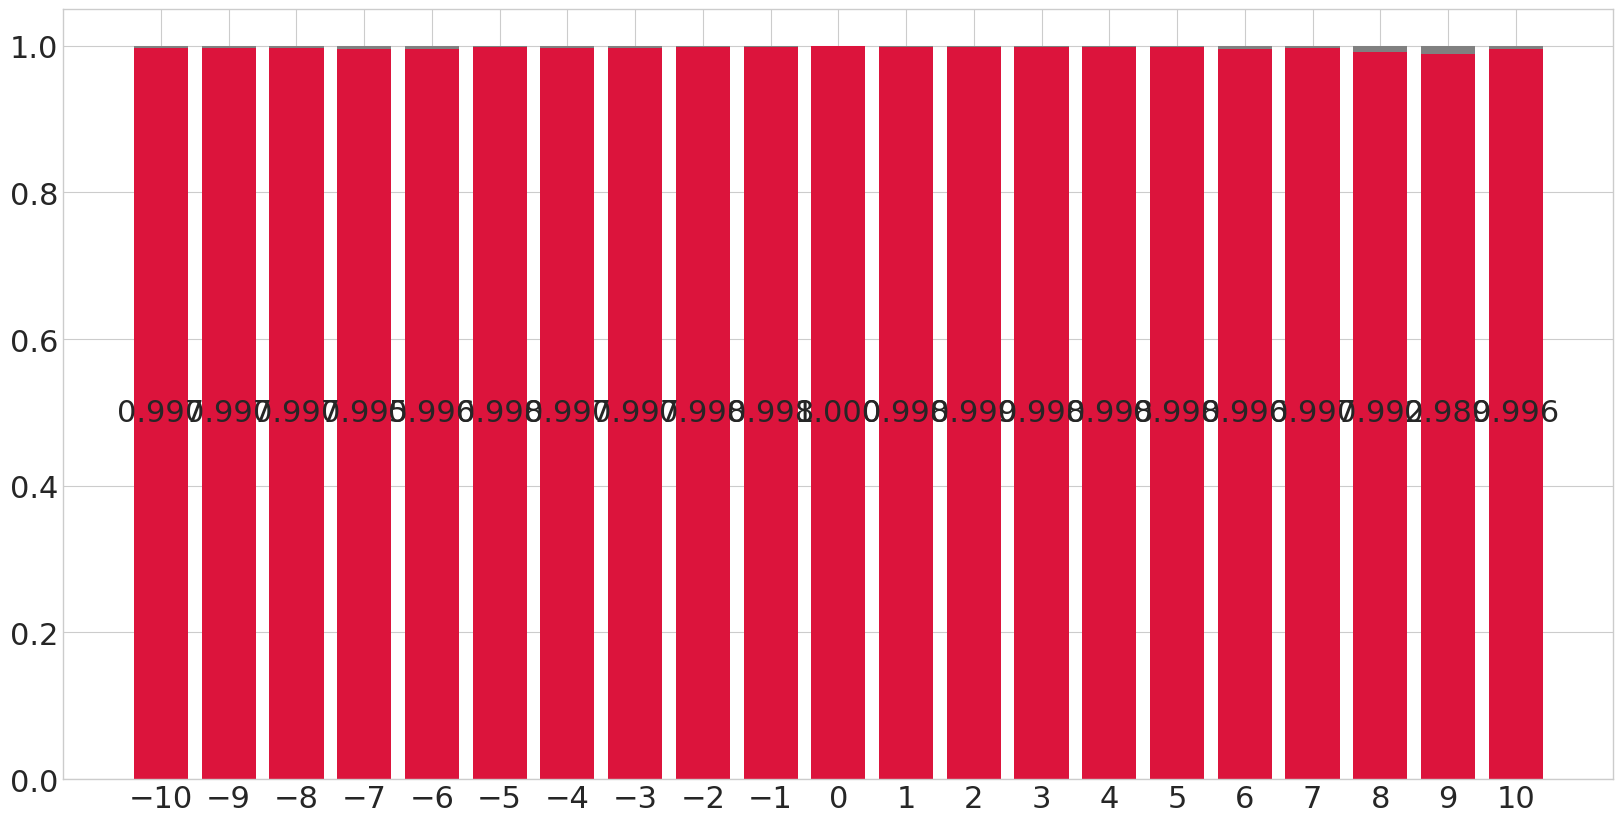

In [26]:
## Plot 11 bars
fig, ax = plt.subplots(1, 1, figsize = (20, 10))
a = ident_arr.mean(axis = 0)
# fill 0-1 with grey and fill range with blue
ax.bar(np.arange(21)-10, np.ones(21), color = "grey")
ax.bar(np.arange(21)-10, a, color = "crimson")
for i in range(21):
    ax.text(i-10, 0.5, f"{a[i]:.3f}", ha = "center", va = "center")
ax.set_xticks(np.arange(21)-10)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/identity_11.pdf")
plt.show()

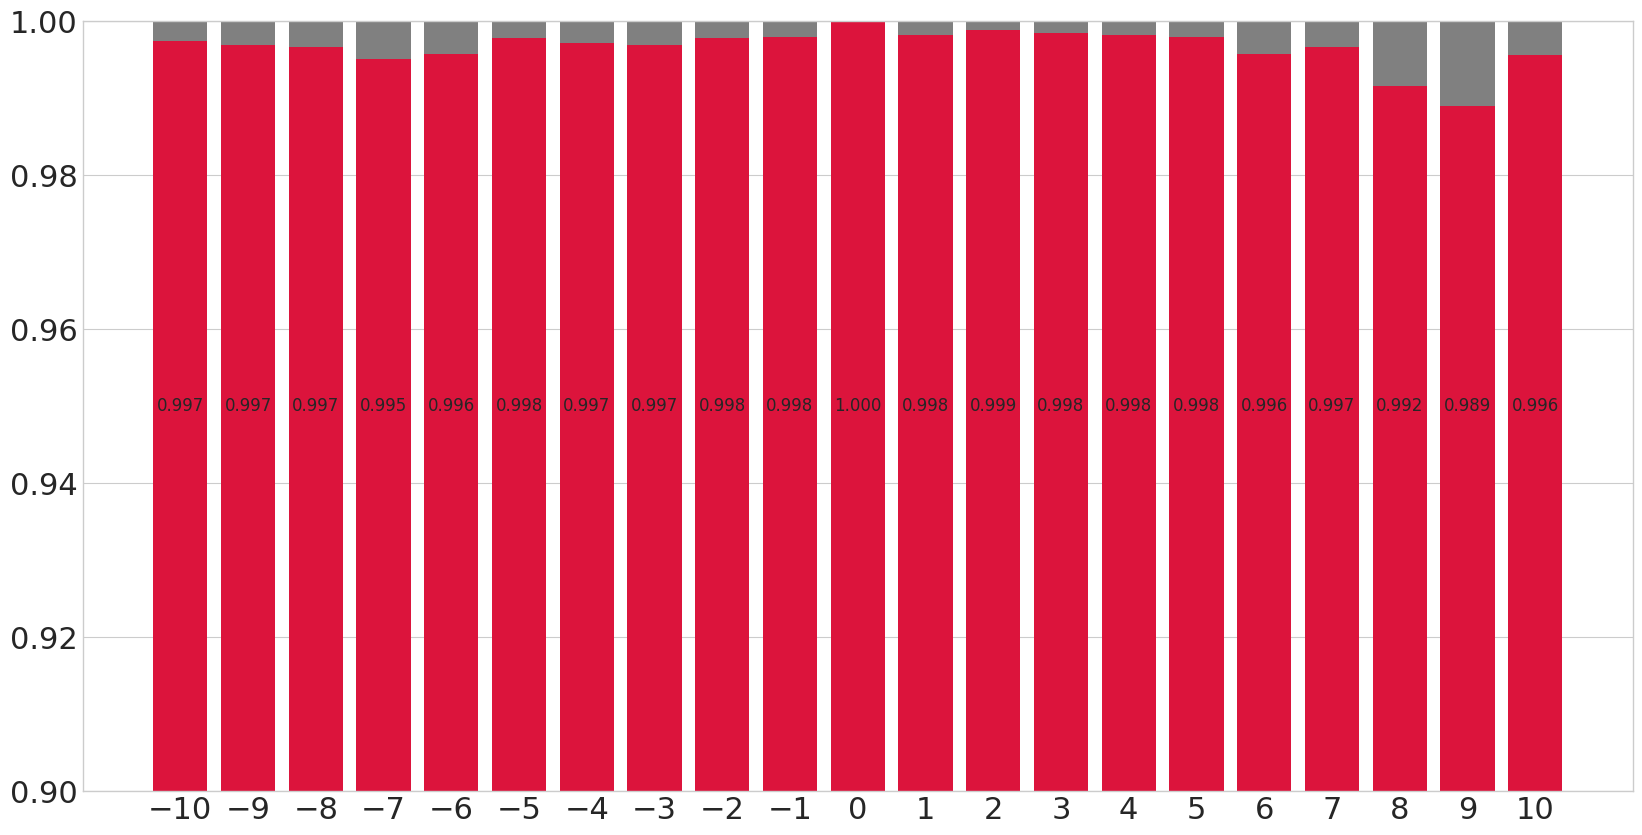

In [27]:
## Plot 11 bars
fig, ax = plt.subplots(1, 1, figsize = (20, 10))
a = ident_arr.mean(axis = 0)
# fill 0-1 with grey and fill range with blue
ax.bar(np.arange(21)-10, np.ones(21), color = "grey")
ax.bar(np.arange(21)-10, a, color = "crimson")
for i in range(21):
    ax.text(i-10, 0.95, f"{a[i]:.3f}", ha = "center", va = "center", fontsize = 12)
    # ax.errorbar(i-10, a[i], yerr = ci95[i], fmt = "none", color = "black")
ax.set_xticks(np.arange(21)-10)
ax.set_ylim(0.9,1.0)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/identity_11.pdf")
plt.show()

In [28]:
def get_alignment_accuracy(align_pairs, pos_rm, ref_seq, query_seq):
    pos_ref = np.array([align_pairs[x] for x in np.arange(pos_rm-10, pos_rm+11)])
    mismatches = np.array(list(query_seq)) != np.array([ref_seq[x] if x is not None else "X" for x in pos_ref])
    insertions = pd.isna(pos_ref)
    deletions = np.diff(pd.Series(pos_ref).ffill().bfill()) > 1
    deletions = np.concatenate([deletions[:10], [False], deletions[10:]])
    ins_del_mis = np.stack([insertions, deletions, mismatches], axis = 1)
    return ins_del_mis


In [29]:
block_df["pos_RM_ref"] = block_df.apply(lambda x: x["align_pairs"][x["pos_RM"]], axis = 1)

In [30]:
block_df_samp["ins_del_mis"] = block_df_samp.apply(lambda x: get_alignment_accuracy(x["align_pairs"], x["pos_RM"], ref_seq, x["motif"]), axis = 1)

In [31]:
block_df_samp.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/block/alignment.pkl")

OSError: Cannot save file into a non-existent directory: '/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/block'

In [32]:
align_arr = np.stack(block_df_samp["ins_del_mis"].values, axis = 0)
ins_arr = align_arr[:,:,0].mean(axis = 0)
del_arr = align_arr[:,:,1].mean(axis = 0)
mis_arr = align_arr[:,:,2].mean(axis = 0)
align_arr_dict = {"insertion": ins_arr, "deletion": del_arr, "mismatch": mis_arr}

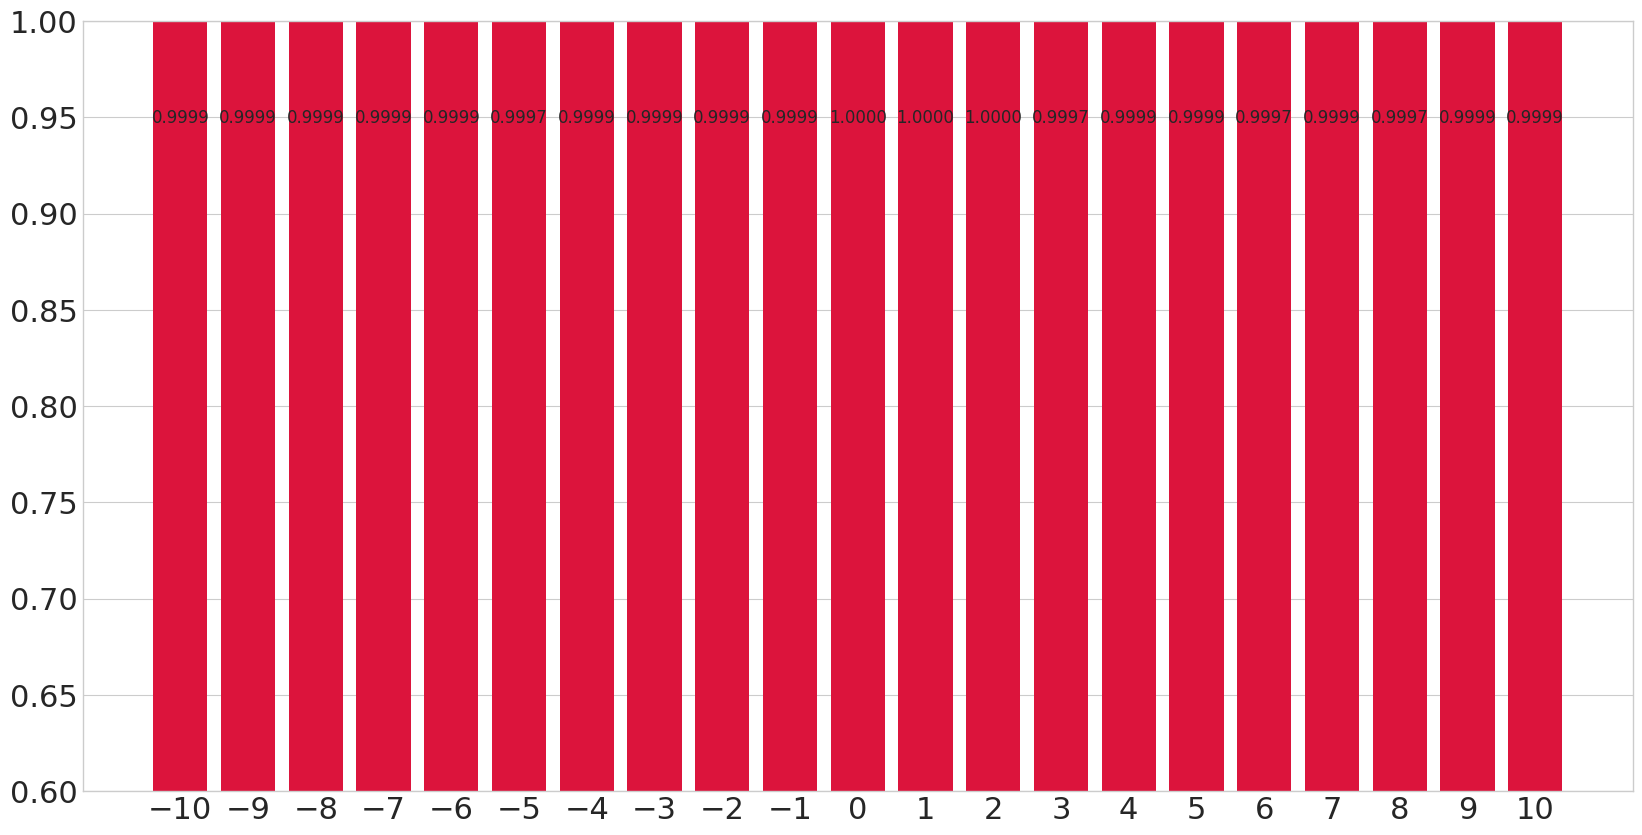

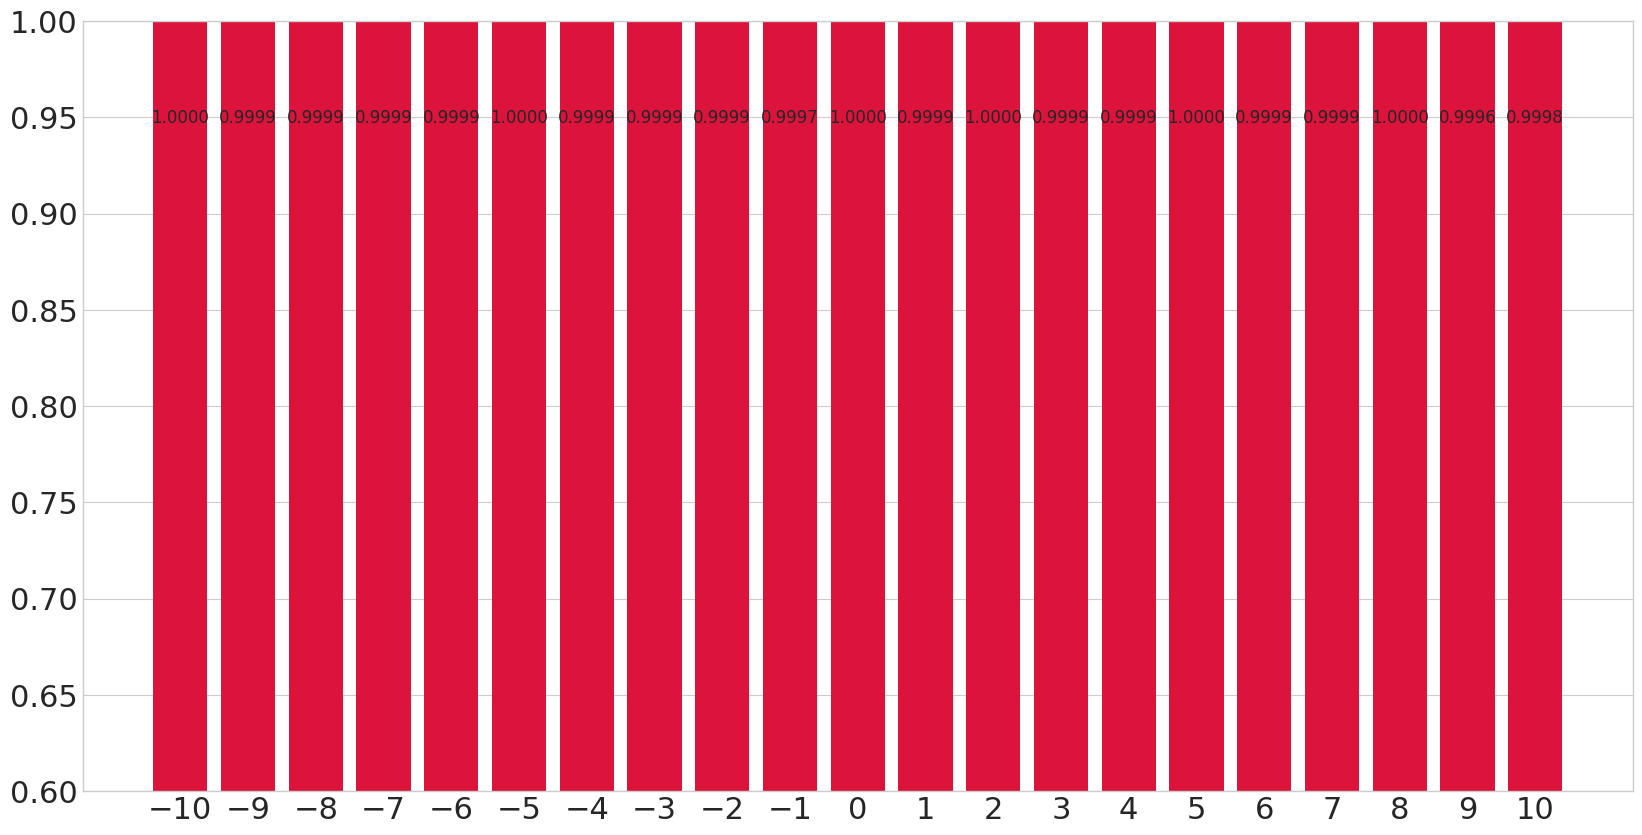

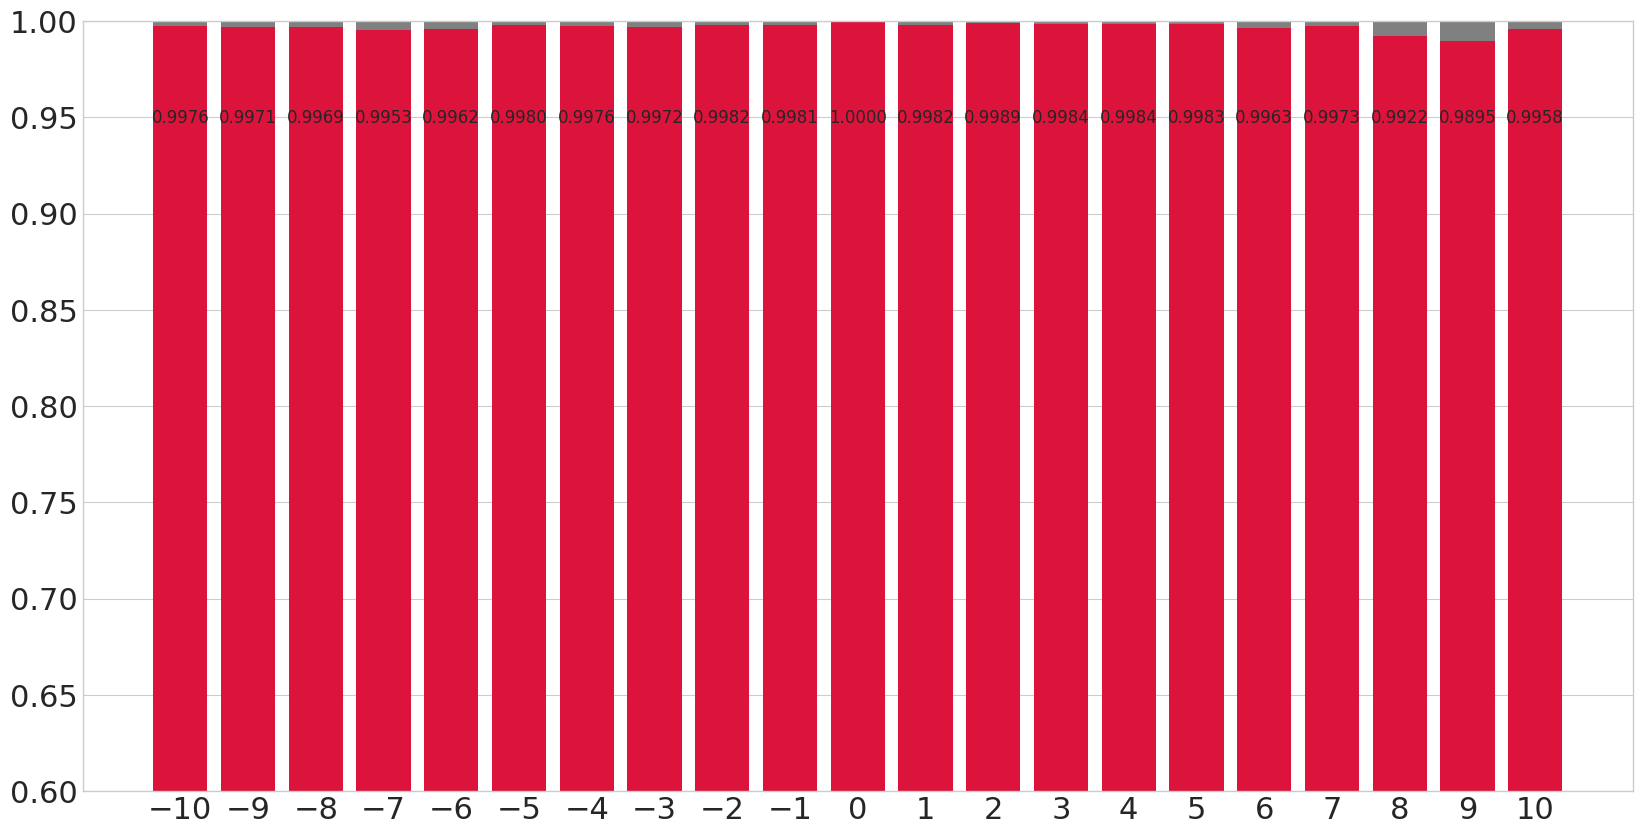

In [33]:
for k, v in align_arr_dict.items():
    ## Plot 11 bars
    fig, ax = plt.subplots(1, 1, figsize = (20, 10))
    # fill 0-1 with grey and fill range with blue
    ax.bar(np.arange(21)-10, np.ones(21), color = "grey")
    ax.bar(np.arange(21)-10, 1-v, color = "crimson")
    for i in range(21):
        ax.text(i-10, 0.95, f"{1-v[i]:.4f}", ha = "center", va = "center", fontsize = 12)
    #     ax.errorbar(i-10, a[i], yerr = ci95[i], fmt = "none", color = "black")
    ax.set_xticks(np.arange(21)-10)
    ax.set_ylim(0.6,1.0)
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/{k}.pdf")
    plt.show()

In [34]:
print(np.median(a))

0.9971609209457638


In [35]:
a2 = np.concatenate([a[:10], a[-10:]])
print(np.median(a2))

0.9970532857471075
